# Árboles de decisión

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from utils2 import get_classifier_metrics
import pickle

##  1. Árbol de Clasificación

### Paso 1. Lectura del conjunto de datos procesado

In [93]:
file_path = '/workspaces/CarlosRestrepo-machine-learning-python/data/processed/diabetes.pkl'

# Abrir el archivo en modo binario de lectura ('rb')
with open(file_path, 'rb') as file:
    # Cargar el objeto (tu DataFrame) usando el manejador de archivo 'file'
    df = pickle.load(file)

### Paso 2. Selección de variables

In [94]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94,28.1,0.167,21,0
5,5.0,116.0,74.0,29.0,0,25.6,0.201,30,0


### Paso 3. Split

In [95]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)
X_train.shape

(593, 8)

In [96]:
y

0      1
1      0
2      1
3      0
5      0
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 742, dtype: int64

In [97]:
y.unique()

array([1, 0])

Siendo:
- La clase `0` negativo en diabetis
- La clase `1` positivo en diabetis

### Paso 4. Análisis y Visualización

<Axes: >

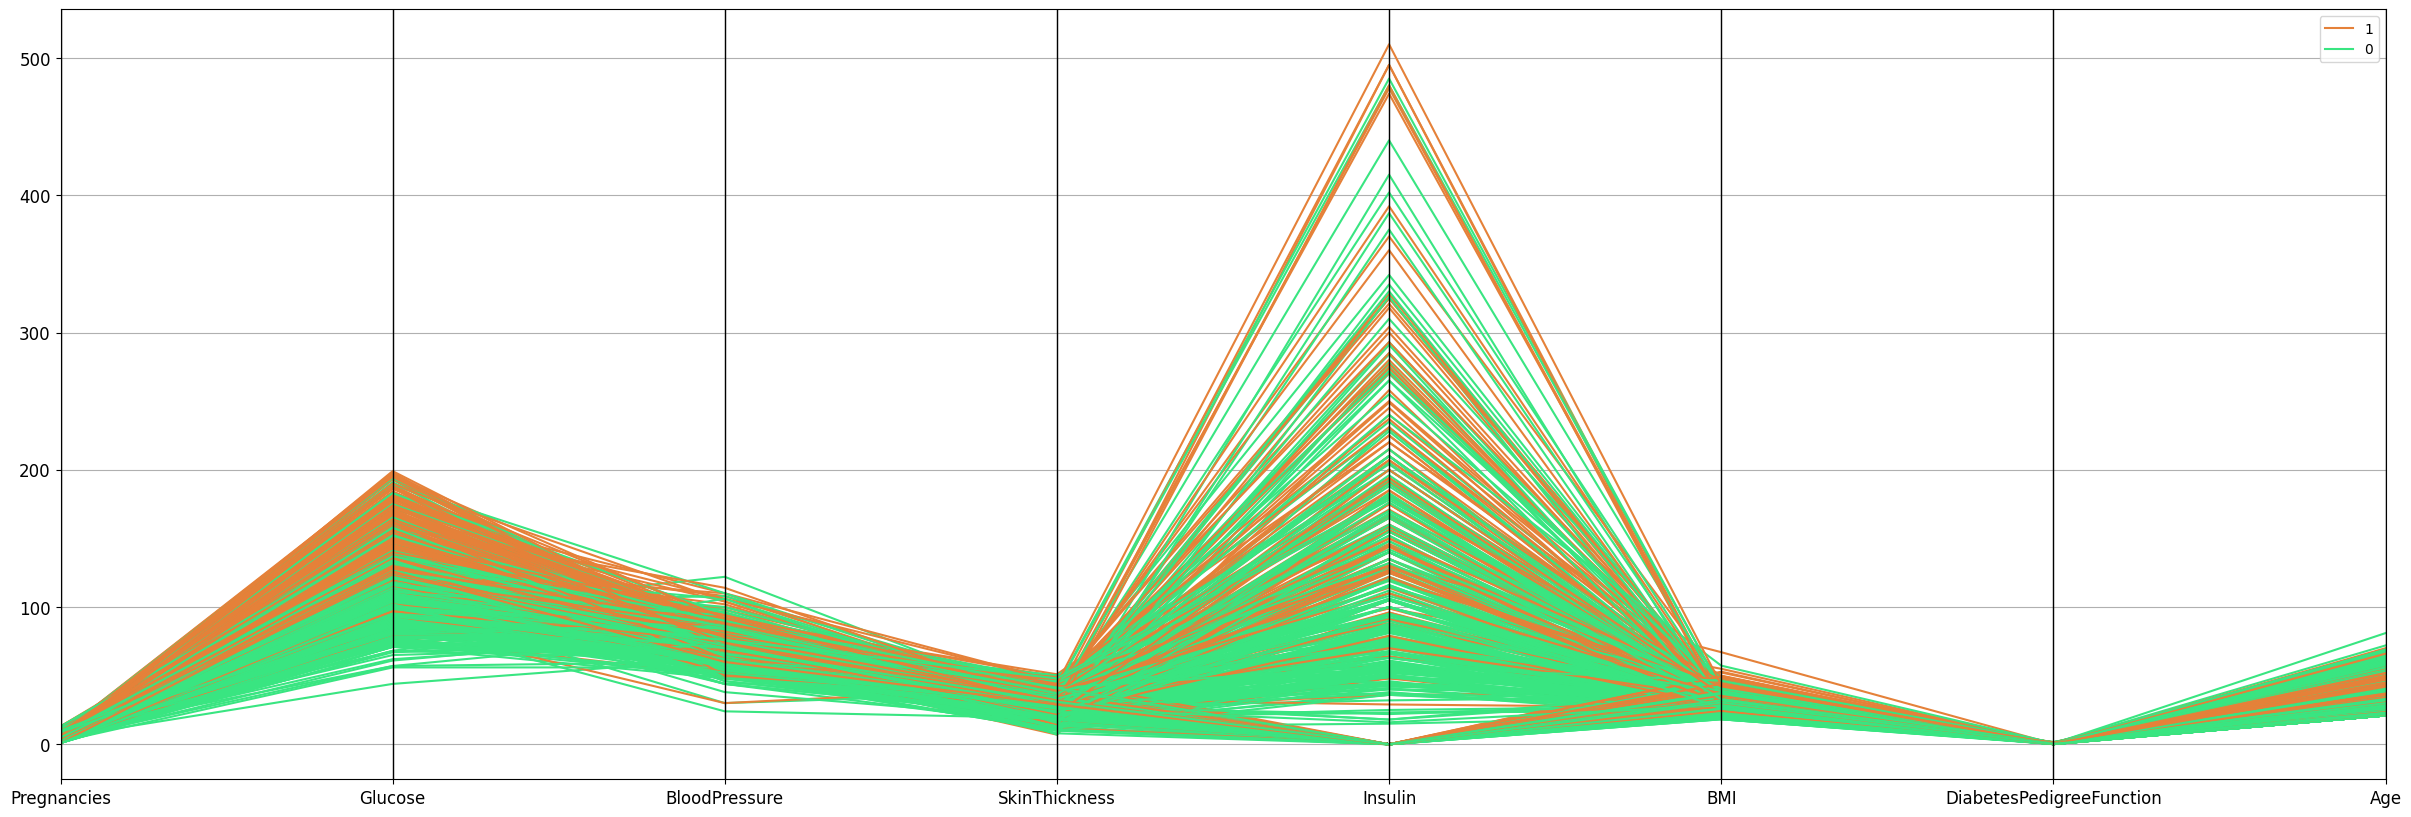

In [98]:
df = X
df['Name'] = y
plt.figure(figsize=(30, 10))
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize'] = 14 

pd.plotting.parallel_coordinates(df,
                                 'Name',
                                 color=('#E58139', '#39E581'))

### Paso 5. Modelado y Ajuste

In [99]:
dt_classifier_model = DecisionTreeClassifier(random_state=18,
                                            max_depth=3,
                                            min_samples_leaf=15,
                                            min_samples_split=4)
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,4
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Ahora visualizamos el árbol de decisiones.
Esta visualización representa todos los pasos que ha seguido el modelo hasta la construcción del árbol.

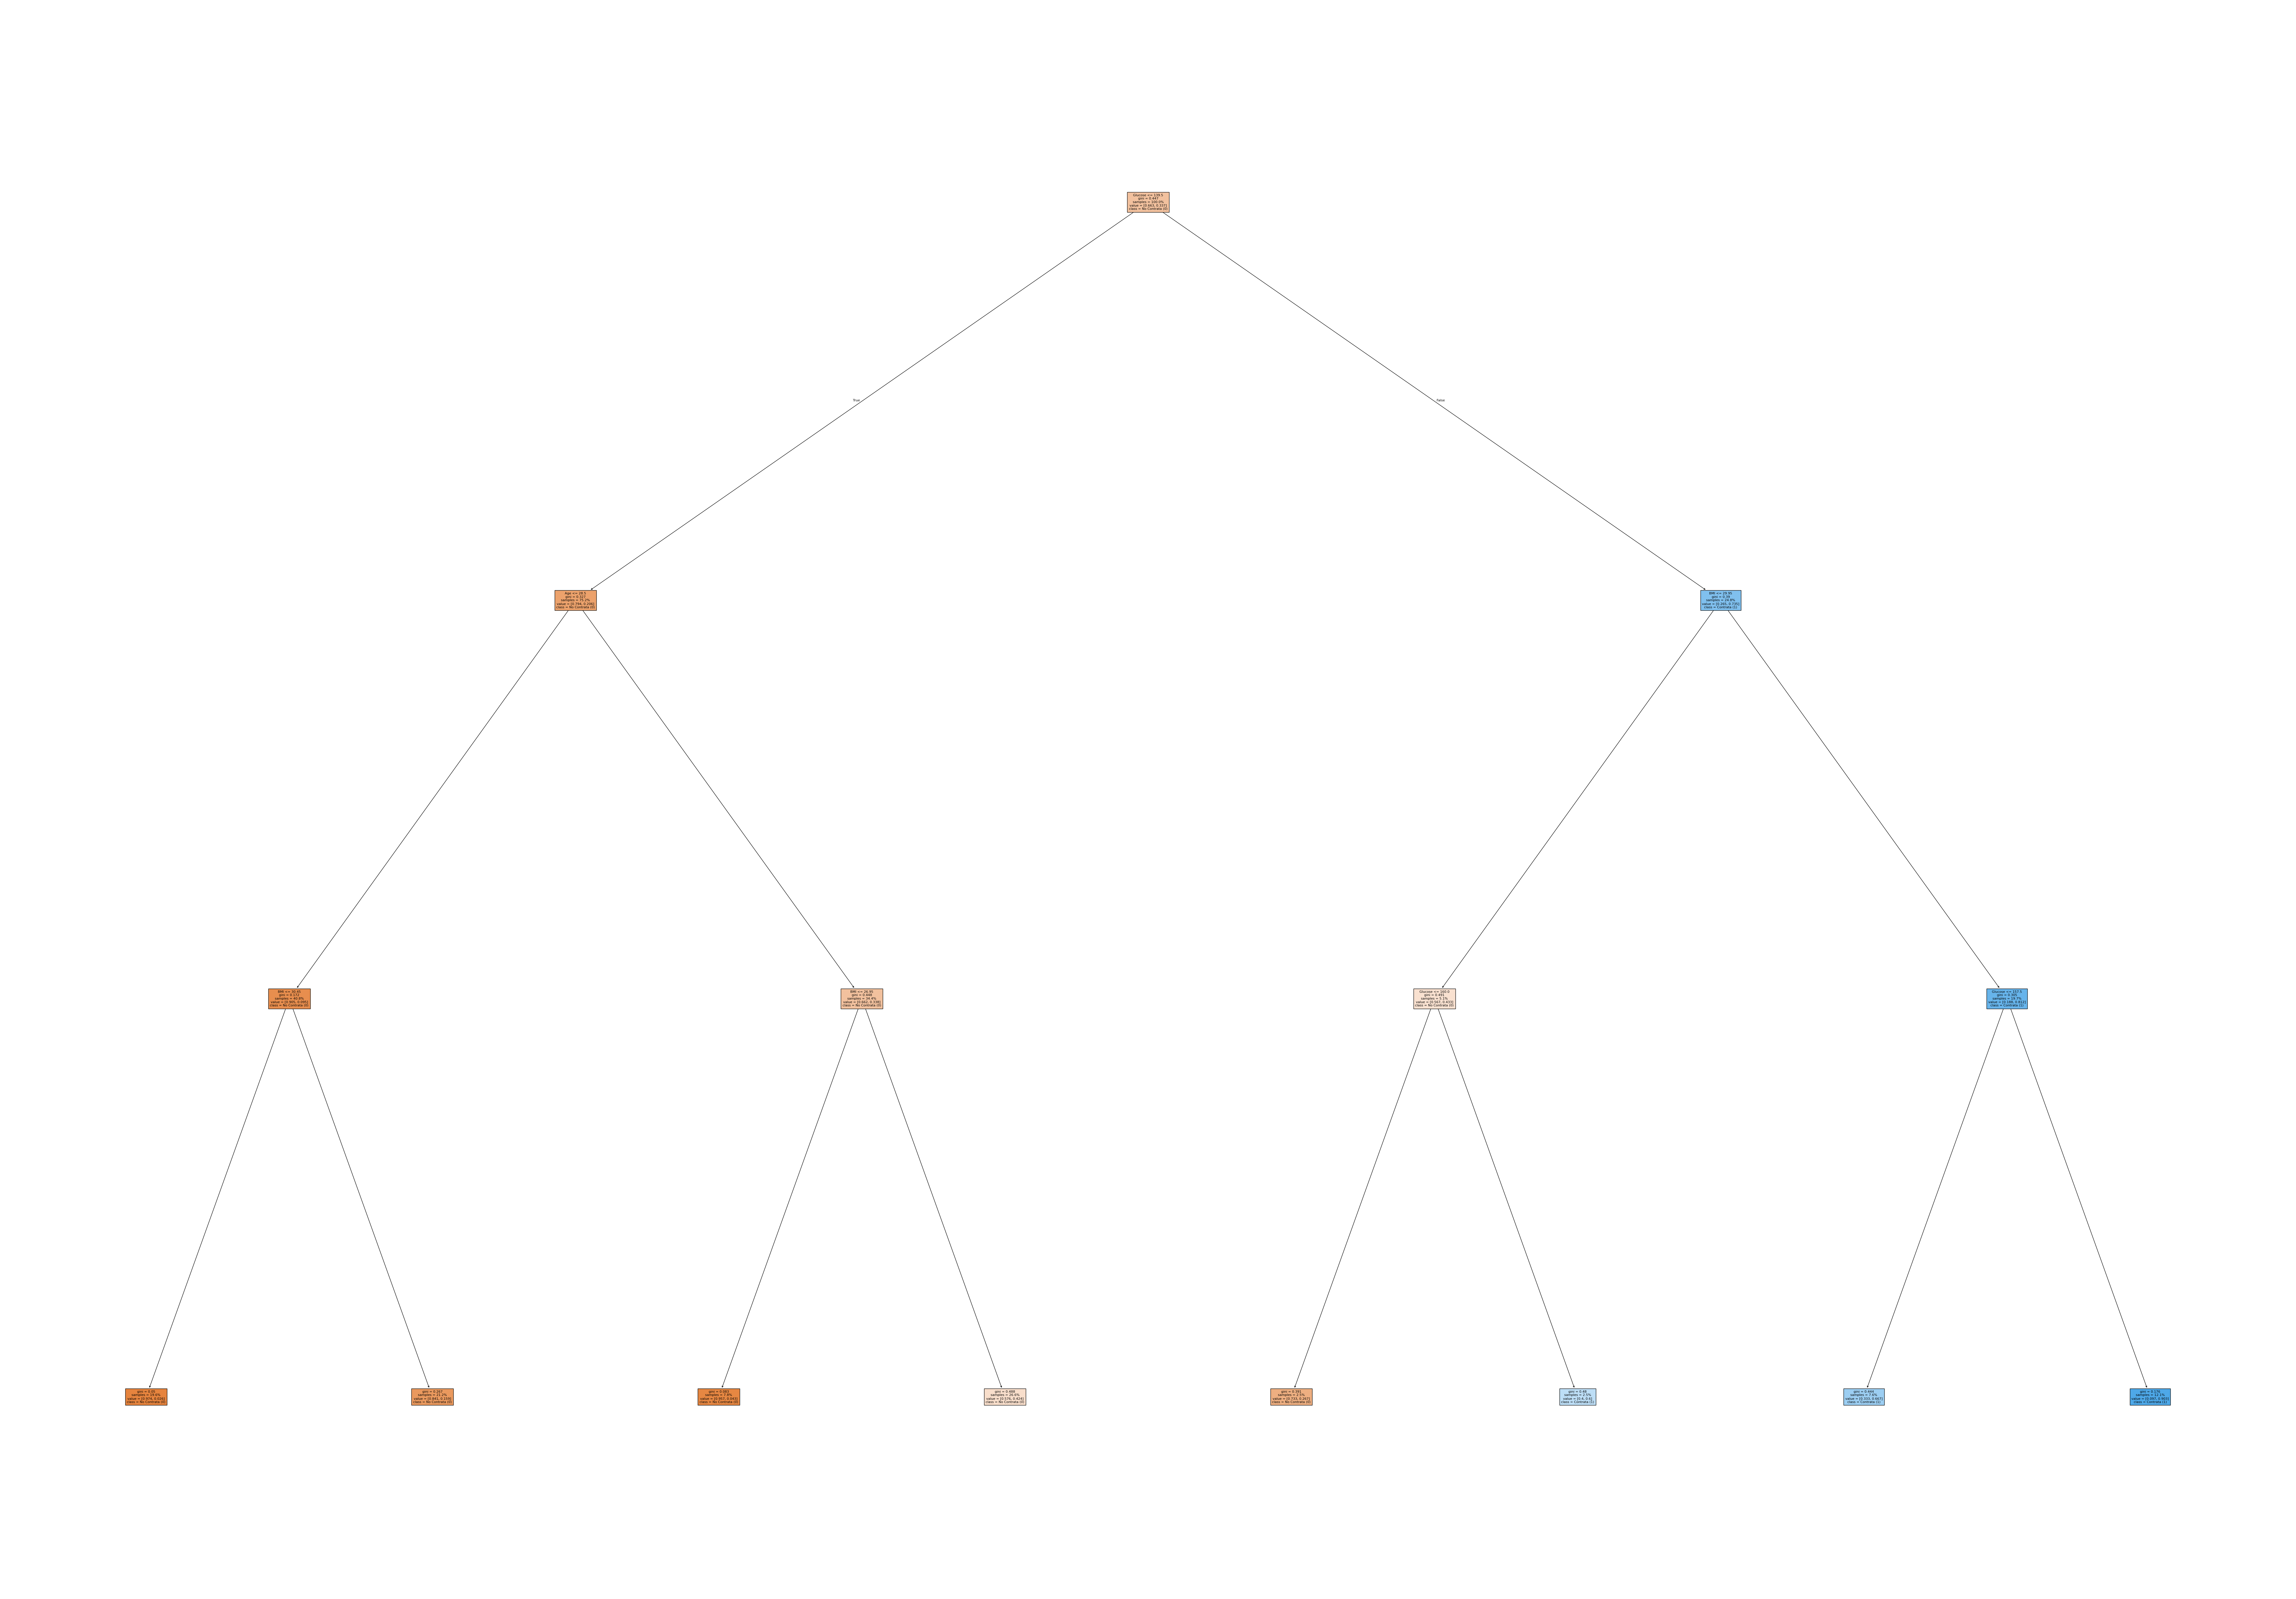

In [100]:
nombres_de_clase = ['No Contrata (0)', 'Contrata (1)']

plt.figure(figsize=(100, 70))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               class_names=nombres_de_clase,
               filled=True,
               fontsize=8,
               proportion=True)
plt.show()

### Paso 6. Predicción

In [101]:
y_pred_test = dt_classifier_model.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [102]:
y_pred_train = dt_classifier_model.predict(X_train)
y_pred_train

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Al evaluar algunas métricas en un escenario multi-clase, hay varias formas de promediar los resultados, siendo las más comunes "micro", "macro" y "weighted".

- Micro Average: Es útil cuando las clases tienen un tamaño similar y cuando quieres tener en cuenta todas las instancias por igual.

In [103]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.790894,0.790894,0.790894,0.790894
Test set,0.657718,0.657718,0.657718,0.657718


- Macro Average: Es adecuado cuando se quiere evaluar el rendimiento del modelo en cada clase de forma independiente y las clases son igualmente importantes.

In [104]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, 'macro')

,Accuracy,F1 Score,Precision,Recall
Train set,0.790894,0.740653,0.789818,0.724377
Test set,0.657718,0.553447,0.610833,0.565350


- Weighted Average: Es ideal cuando las clases están desequilibradas y se quiere tener en cuenta el tamaño de cada clase en la evaluación global.

In [105]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average='weighted')

,Accuracy,F1 Score,Precision,Recall
Train set,0.790894,0.777804,0.790449,0.790894
Test set,0.657718,0.615720,0.630794,0.657718


### Paso 7. Guardar el modelo

In [106]:
with open('../models/decision-tree-diabetes.pkl', 'wb') as file:
    pickle.dump(dt_classifier_model, file)